In [71]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

In [72]:
df = pd.read_csv("accident_prediction_india.csv",sep=",", encoding='latin1')

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    3000 non-null   object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

In [74]:
df.head()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [75]:
print("Data Types:\n", df.dtypes)

Data Types:
 State Name                     object
City Name                      object
Year                            int64
Month                          object
Day of Week                    object
Time of Day                    object
Accident Severity              object
Number of Vehicles Involved     int64
Vehicle Type Involved          object
Number of Casualties            int64
Number of Fatalities            int64
Weather Conditions             object
Road Type                      object
Road Condition                 object
Lighting Conditions            object
Traffic Control Presence       object
Speed Limit (km/h)              int64
Driver Age                      int64
Driver Gender                  object
Driver License Status          object
Alcohol Involvement            object
Accident Location Details      object
dtype: object


In [76]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64


In [77]:
from sklearn.impute import SimpleImputer
df = df.dropna(axis=1, how='all')

imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

df_imputed.columns = df_imputed.columns.str.strip()

In [78]:
print("Missing Values in df_imputed after imputation:\n", df_imputed.isnull().sum())

Missing Values in df_imputed after imputation:
 State Name                     0
City Name                      0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Accident Severity              0
Number of Vehicles Involved    0
Vehicle Type Involved          0
Number of Casualties           0
Number of Fatalities           0
Weather Conditions             0
Road Type                      0
Road Condition                 0
Lighting Conditions            0
Traffic Control Presence       0
Speed Limit (km/h)             0
Driver Age                     0
Driver Gender                  0
Driver License Status          0
Alcohol Involvement            0
Accident Location Details      0
dtype: int64


In [79]:
print("Target Distribution:\n", df['Accident Severity'].value_counts())

Target Distribution:
 Accident Severity
Minor      1034
Fatal       985
Serious     981
Name: count, dtype: int64


In [95]:
print("Unique values in 'Accident Location Details':")
display(df['Accident Location Details'].value_counts())


Unique values in 'Accident Location Details':


,count
Accident Location Details,
Intersection,789
Bridge,765
Straight Road,740
Curve,706


In [100]:
accident_hotspots_simplified = df_imputed.groupby([
    'State Name',
    'Road Type',
    'Weather Conditions'
]).size().reset_index(name='Accident Count')


top_accident_hotspots_simplified = accident_hotspots_simplified.sort_values(by='Accident Count', ascending=False).head(5)

print("Top 5 Most Accident-Prone Combinations (State, Road Type, Weather):")
display(top_accident_hotspots_simplified)

Top 5 Most Accident-Prone Combinations (State, Road Type, Weather):


,State Name,Road Type,Weather Conditions,Accident Count
365,Meghalaya,State Highway,Hazy,12
202,Himachal Pradesh,National Highway,Rainy,11
244,Jharkhand,State Highway,Clear,11
385,Mizoram,State Highway,Hazy,11
451,Puducherry,Village Road,Foggy,10


/tmp/ipykernel_2567/200920510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, palette='magma')


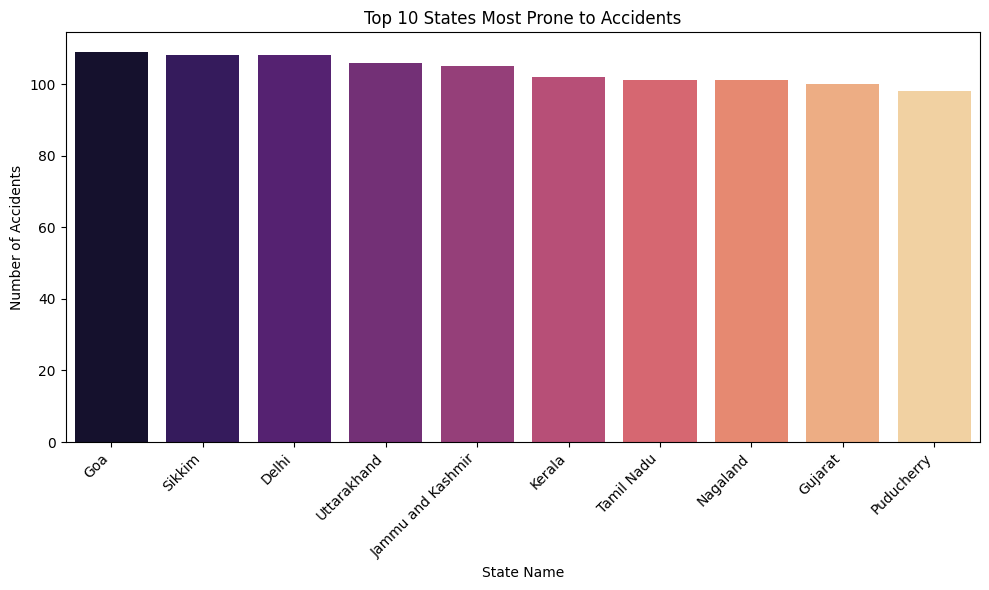

In [97]:
top_states = df_imputed['State Name'].value_counts().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.index, y=top_states.values, palette='magma')
plt.title('Top 10 States Most Prone to Accidents')
plt.xlabel('State Name')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

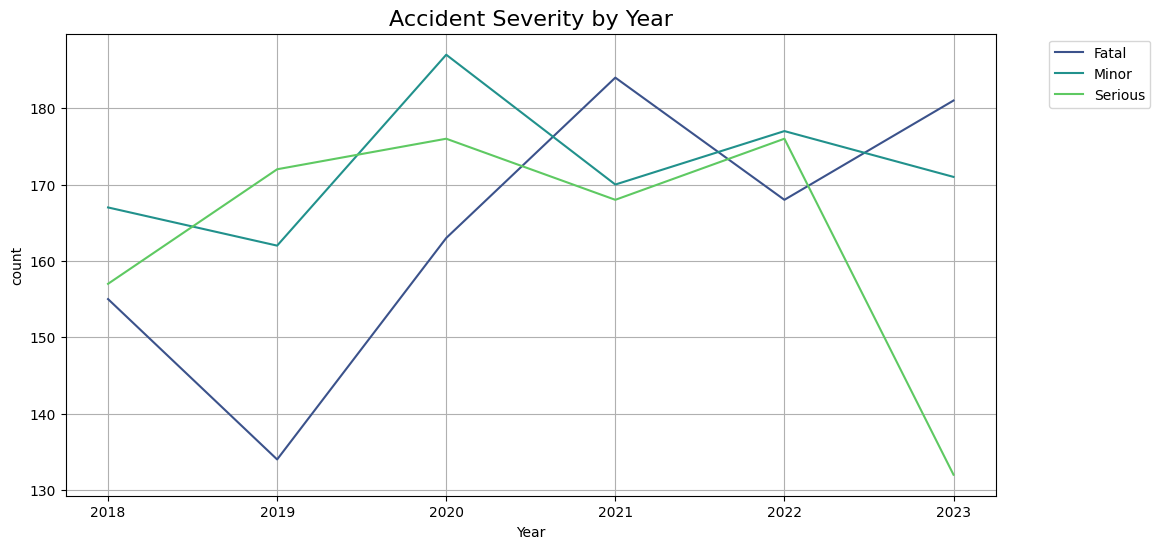

In [80]:
year_accident_severity = df.groupby(['Year','Accident Severity']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
ax = sns.lineplot(year_accident_severity, x='Year', y='count', hue='Accident Severity', palette='viridis')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('Accident Severity by Year',fontsize=16)
plt.grid()
plt.show()

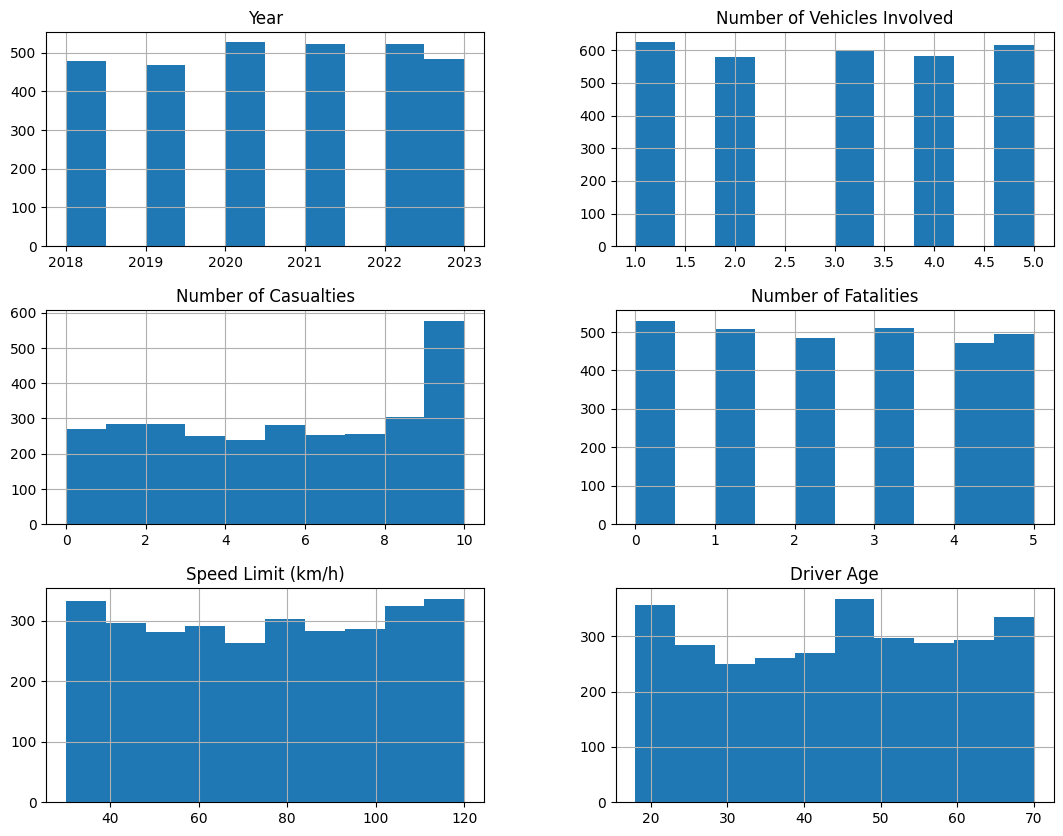

In [81]:
num_df = df.select_dtypes(include=['number'])
num_df.hist(figsize=(13,10))
plt.show()

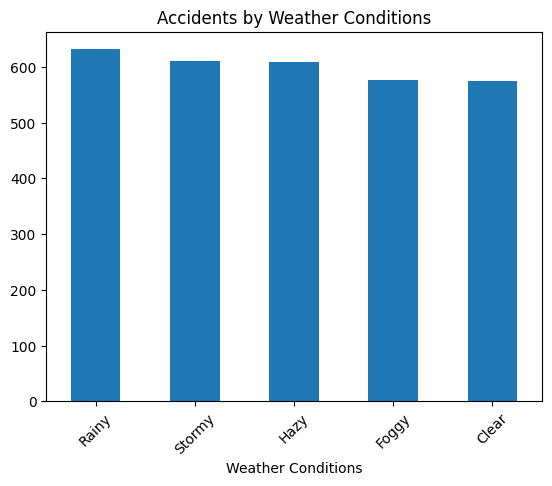

In [82]:
df['Weather Conditions'].value_counts().plot(kind='bar', title="Accidents by Weather Conditions")
plt.xticks(rotation=45)
plt.show()

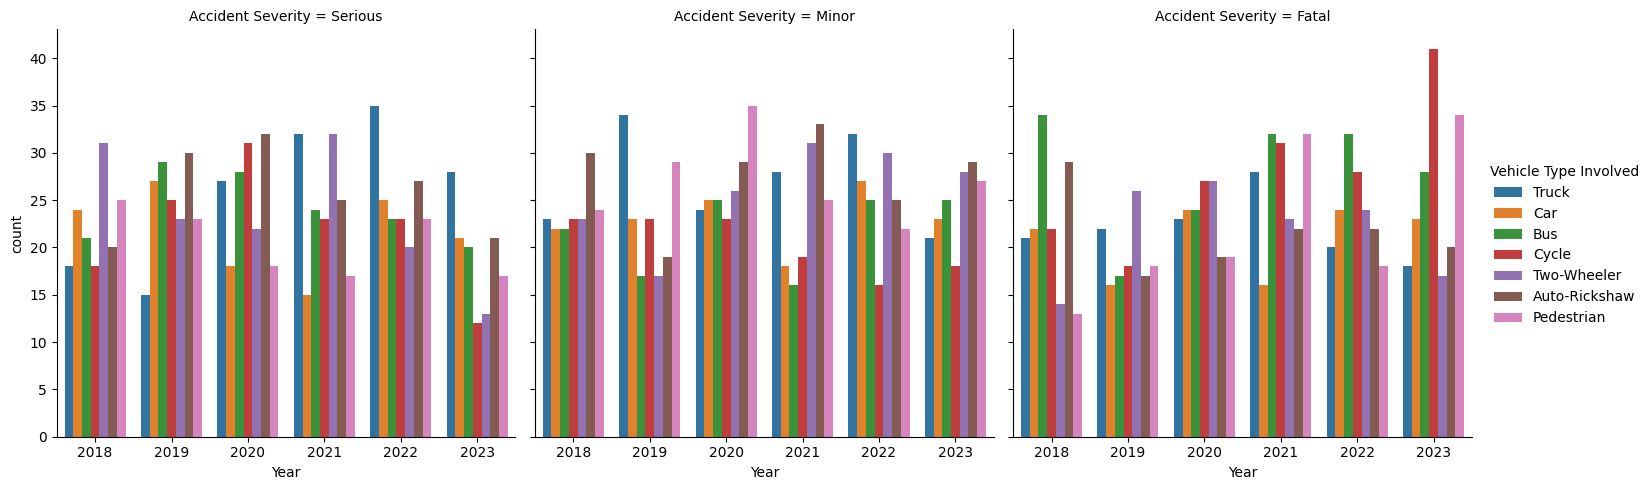

In [83]:
sns.catplot(data=df,
            x='Year',
            kind='count',
            col='Accident Severity',
            hue='Vehicle Type Involved',
            col_wrap=3,
            height=5,
            aspect=1
           )
plt.show()

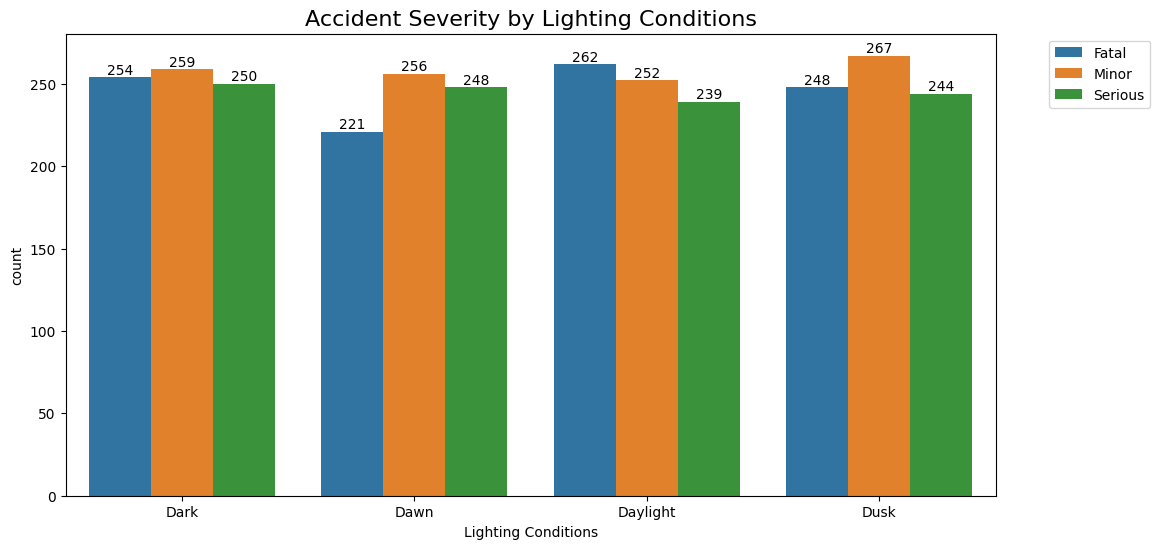

In [84]:
condition = df.groupby(['Lighting Conditions','Accident Severity']).size().reset_index(name = 'count')

plt.figure(figsize=(12,6))
ax = sns.barplot(condition, x='Lighting Conditions', y='count', hue='Accident Severity')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('Accident Severity by Lighting Conditions',fontsize=16)
plt.show()

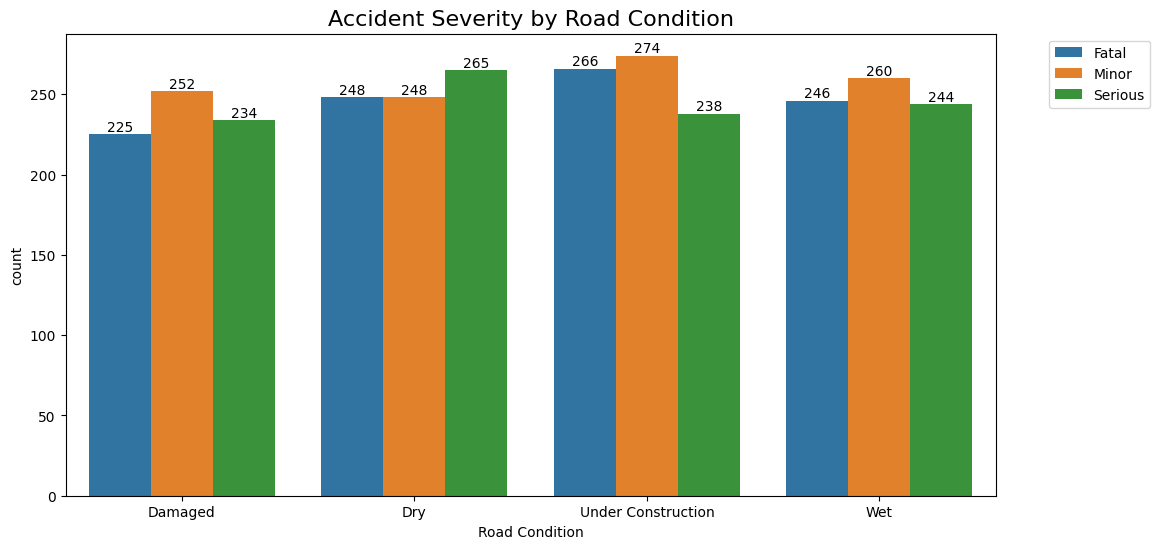

In [85]:
condition_2 = df.groupby(['Road Condition','Accident Severity']).size().reset_index(name = 'count')

plt.figure(figsize=(12,6))
ax = sns.barplot(condition_2, x='Road Condition', y='count', hue='Accident Severity')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('Accident Severity by Road Condition',fontsize=16)
plt.show()

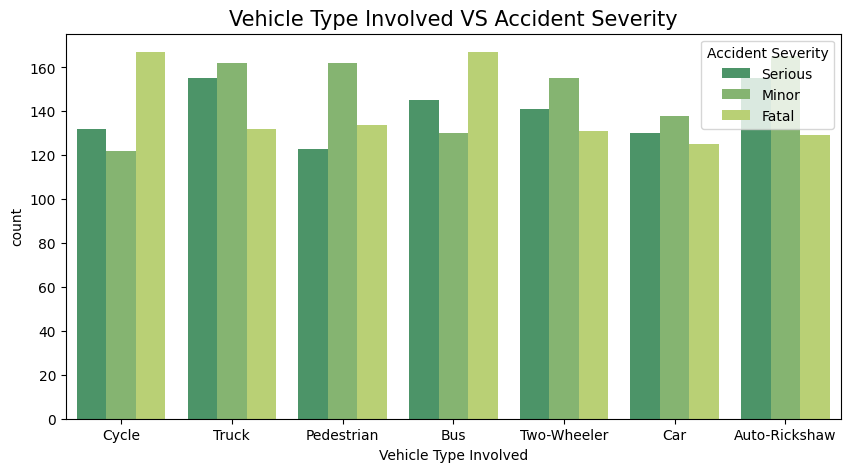

In [86]:
df['Vehicle Type Involved'].value_counts()
plt.figure(figsize=(10,5))
plt.title('Vehicle Type Involved VS Accident Severity', fontsize=15)
sns.countplot(x=df['Vehicle Type Involved'],hue=df['Accident Severity'], palette='summer')
plt.show()

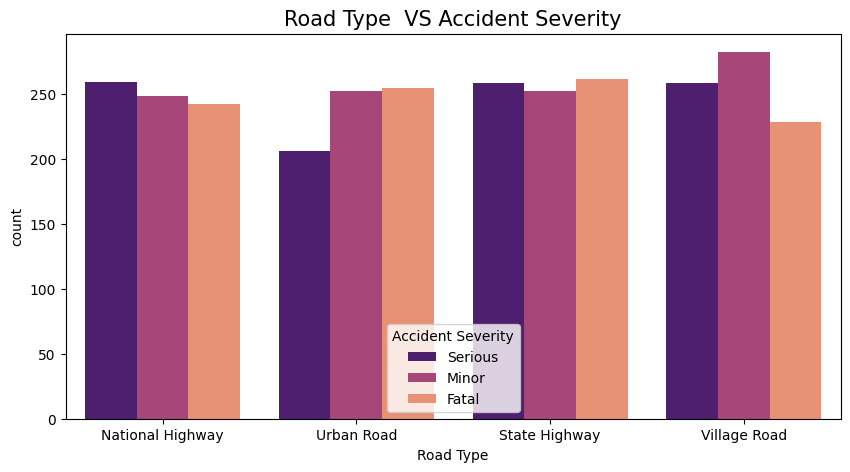

In [87]:
plt.figure(figsize=(10,5))
plt.title('Road Type  VS Accident Severity', fontsize=15)
sns.countplot(x=df['Road Type'],hue=df['Accident Severity'], palette='magma')
plt.show()

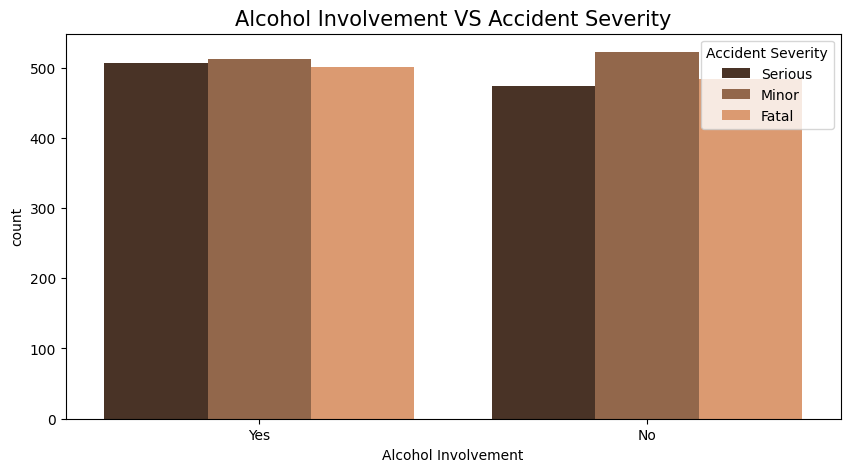

In [88]:
plt.figure(figsize=(10,5))
plt.title('Alcohol Involvement VS Accident Severity', fontsize=15)
sns.countplot(x=df['Alcohol Involvement'],hue=df['Accident Severity'], palette='copper')
plt.show()

/tmp/ipykernel_2567/576755914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vehicles.index, y=top_vehicles.values, palette="rocket_r")


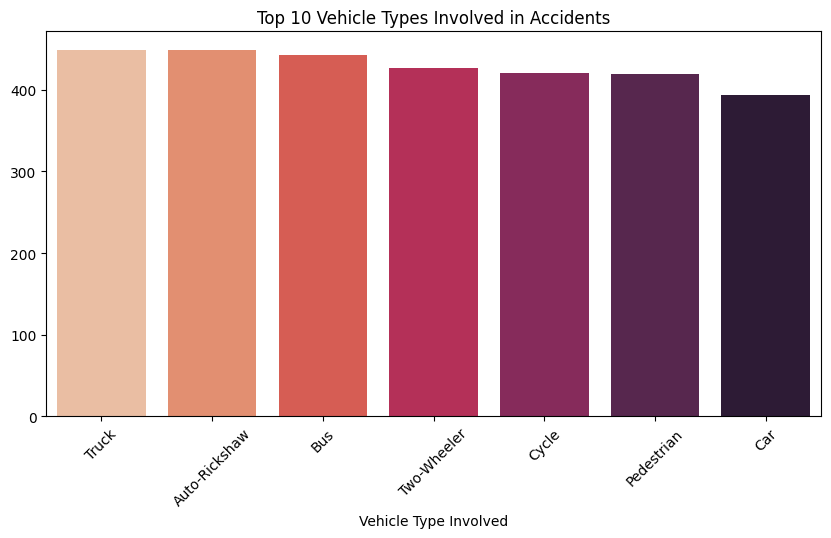

In [89]:
plt.figure(figsize=(10,5))
top_vehicles = df["Vehicle Type Involved"].value_counts().nlargest(10)
sns.barplot(x=top_vehicles.index, y=top_vehicles.values, palette="rocket_r")
plt.xticks(rotation=45)
plt.title("Top 10 Vehicle Types Involved in Accidents")
plt.show()

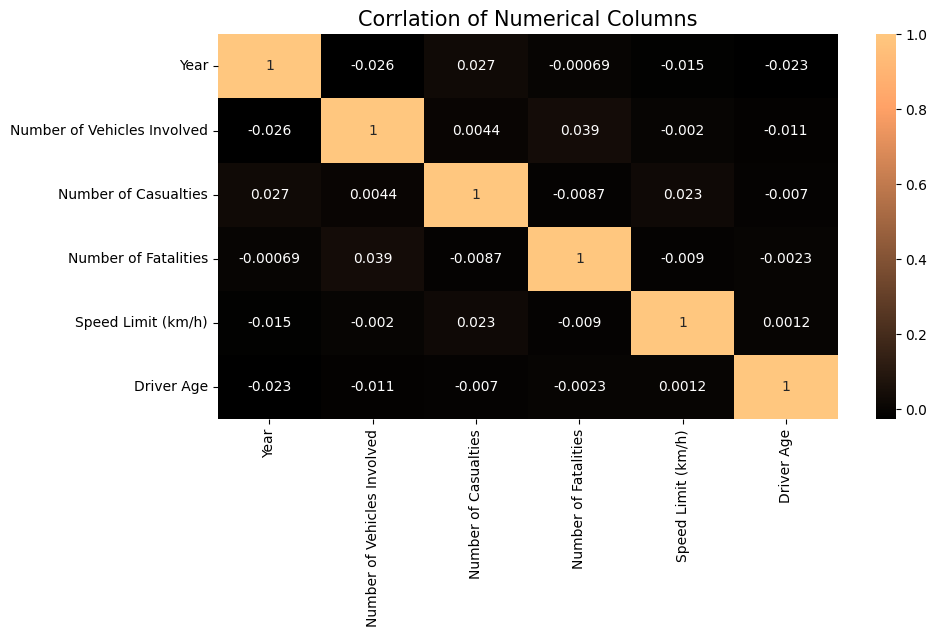

In [90]:
plt.figure(figsize=(10,5))
plt.title('Corrlation of Numerical Columns', fontsize=15)
num_df = df.select_dtypes(include=['number'])
sns.heatmap(num_df.corr(), cmap='copper', annot=True)
plt.show()

In [91]:
y = df_imputed['Accident Severity']


df_features = df_imputed.drop('Accident Severity', axis=1)
df_encoded = pd.get_dummies(df_features, drop_first=True)


print('Features shape after encoding:', df_encoded.shape)


df_model = df_encoded.copy()


X_train, X_test, y_train, y_test = train_test_split(df_model, y, test_size=0.3, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

Features shape after encoding: (3000, 1530)
Shape of X_train: (2100, 1530)
Shape of X_test: (900, 1530)
Shape of y_train: (2100,)
Shape of y_test: (900,)


Prediction Accuracy: 0.35

Classification Report:
               precision    recall  f1-score   support

       Fatal       0.34      0.33      0.34       291
       Minor       0.34      0.42      0.38       309
     Serious       0.36      0.29      0.32       300

    accuracy                           0.35       900
   macro avg       0.35      0.35      0.34       900
weighted avg       0.35      0.35      0.34       900



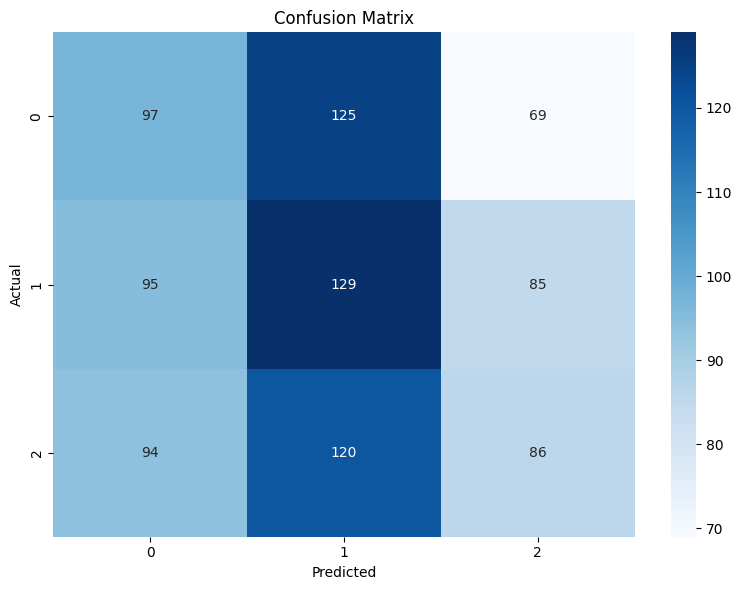

In [92]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Prediction Accuracy: {accuracy:.2f}")


print('\nClassification Report:\n', classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

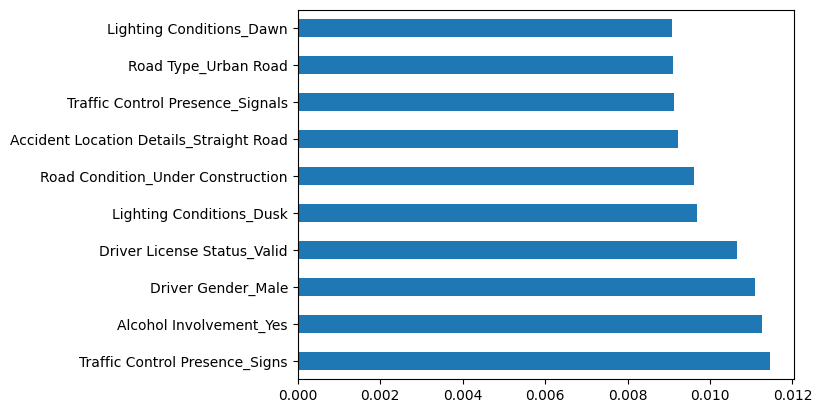

In [93]:
feat_importances = pd.Series(rfc.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()